# Übung: Dimensionsreduktion mit PCA und t-SNE

In diesem Notebook wird die Aufgabe Schritt für Schritt mit dem Iris-Datensatz gelöst.

## Aufgabenstellung: a)

Laden Sie einen geeigneten Datensatz für die Dimensionsreduktion herunter. Sie können grundsätzlich jeden Datensatz Ihrer Wahl verwenden. Besonders bequem ist die Nutzung der Ladefunktion `sklearn.datasets.fetch_openml`, um beliebte Demodatensätze aus der OpenML-Plattform zu laden. Hier ein paar Vorschläge für gelabelte Datensätze:

- MNIST (handgeschriebene Ziffern)
- Iris (Pflanzenmerkmale)
- Wine (Inhaltsstoffe von Wein)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

iris = load_iris()

X = iris.data
y = iris.target
target_names = iris.target_names

df = pd.DataFrame(X, columns=iris.feature_names)
df["class"] = y
df["class_name"] = target_names[y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class,class_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Aufgabenstellung: b)

Untersuchen Sie zunächst den Datensatz. Was enthält er und wie ist er aufgebaut? Bereiten Sie ihn dann für die Dimensionsreduktion vor. Dies kann das Entfernen fehlender Werte, die Normalisierung von Daten oder das Entfernen von Ausreißern beinhalten.

In [2]:
print("Form des Datensatzes:", df.shape)
print("\nSpalten:")
print(df.columns)

print("\nFehlende Werte:")
print(df.isnull().sum())

print("\nAnzahl pro Klasse:")
print(df["class_name"].value_counts())

print("\nStatistische Übersicht:")
print(df.describe())

Form des Datensatzes: (150, 6)

Spalten:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'class', 'class_name'],
      dtype='str')

Fehlende Werte:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
class                0
class_name           0
dtype: int64

Anzahl pro Klasse:
class_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistische Übersicht:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   

In [3]:
# Die vier numerischen Merkmale werden standardisiert.
# Dadurch haben alle Merkmale Mittelwert 0 und Standardabweichung 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## Aufgabenstellung: c)

Wenden Sie PCA und t-SNE auf die vorverarbeiteten Daten an und visualisieren Sie die Ergebnisse. Sie können die reduzierten Dimensionen in einem 2D- und/oder 3D-Plot darstellen.

Falls Ihre Daten Klassenzugehörigkeiten enthalten, plotten Sie diese mit, zum Beispiel durch farbliche Markierung. Erkennen Sie die Klassen im niedrigdimensionalen Raum wieder?

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Erklärte Varianz pro Komponente:", pca.explained_variance_ratio_)
print("Gesamte erklärte Varianz:", pca.explained_variance_ratio_.sum())

Erklärte Varianz pro Komponente: [0.72962445 0.22850762]
Gesamte erklärte Varianz: 0.9581320720000166


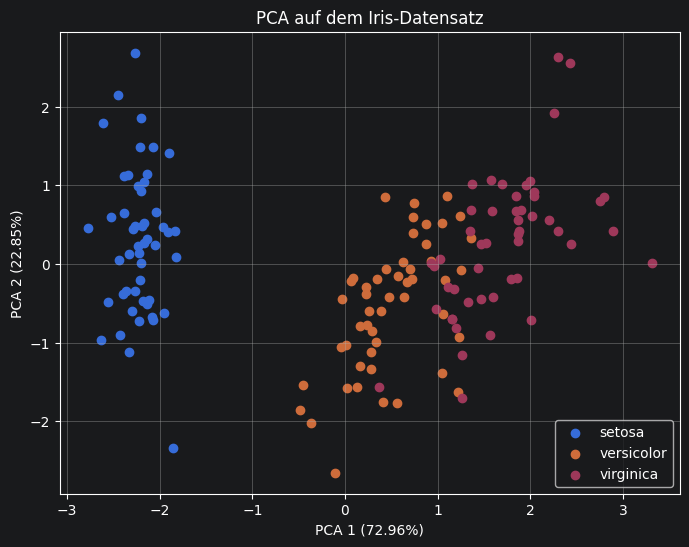

In [10]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(target_names):
    plt.scatter(
        X_pca[y == class_id, 0],
        X_pca[y == class_id, 1],
        label=class_name
    )

plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.title("PCA auf dem Iris-Datensatz")
plt.legend()
plt.grid(True)
plt.show()

## t-SNE:

In [11]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

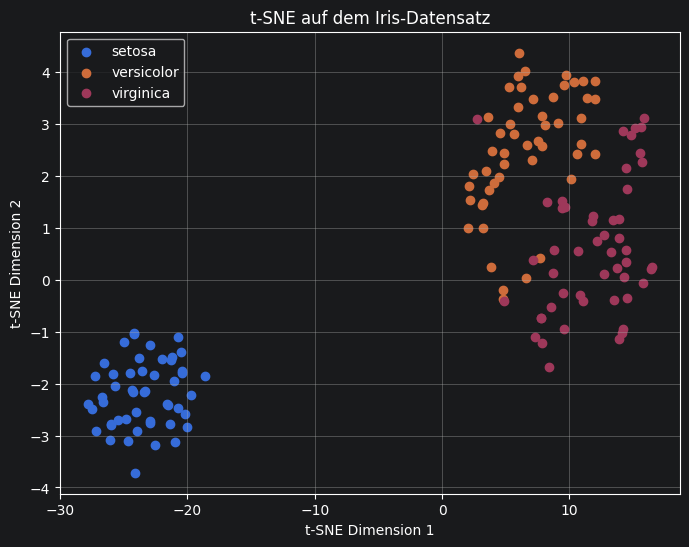

In [12]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(target_names):
    plt.scatter(
        X_tsne[y == class_id, 0],
        X_tsne[y == class_id, 1],
        label=class_name
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE auf dem Iris-Datensatz")
plt.legend()
plt.grid(True)
plt.show()

## Aufgabenstellung: d)

Experimentieren Sie mit verschiedenen Hyperparametern der Methoden, um zu sehen, wie sich die Ergebnisse ändern. Testen Sie zum Beispiel verschiedene Werte für die Anzahl der reduzierten Dimensionen oder den Wert der Perplexität bei t-SNE.

Was bedeuten die variierten Parameter? Dokumentieren Sie Ihre Beobachtungen.

In [13]:
pca_full = PCA(n_components=4)
X_pca_full = pca_full.fit_transform(X_scaled)

print("Erklärte Varianz pro Komponente:")
print(pca_full.explained_variance_ratio_)

print("\nKumulierte erklärte Varianz:")
print(np.cumsum(pca_full.explained_variance_ratio_))

Erklärte Varianz pro Komponente:
[0.72962445 0.22850762 0.03668922 0.00517871]

Kumulierte erklärte Varianz:
[0.72962445 0.95813207 0.99482129 1.        ]


**Beobachtung PCA-Hyperparameter:**

`n_components` gibt an, auf wie viele Dimensionen die Daten reduziert werden. Bei `n_components=2` kann man die Daten gut in einem 2D-Plot darstellen. Beim Iris-Datensatz erklären die ersten zwei Komponenten bereits einen großen Teil der Varianz. Mehr Komponenten behalten mehr Information, sind aber schlechter direkt visualisierbar.

## t-SNE:

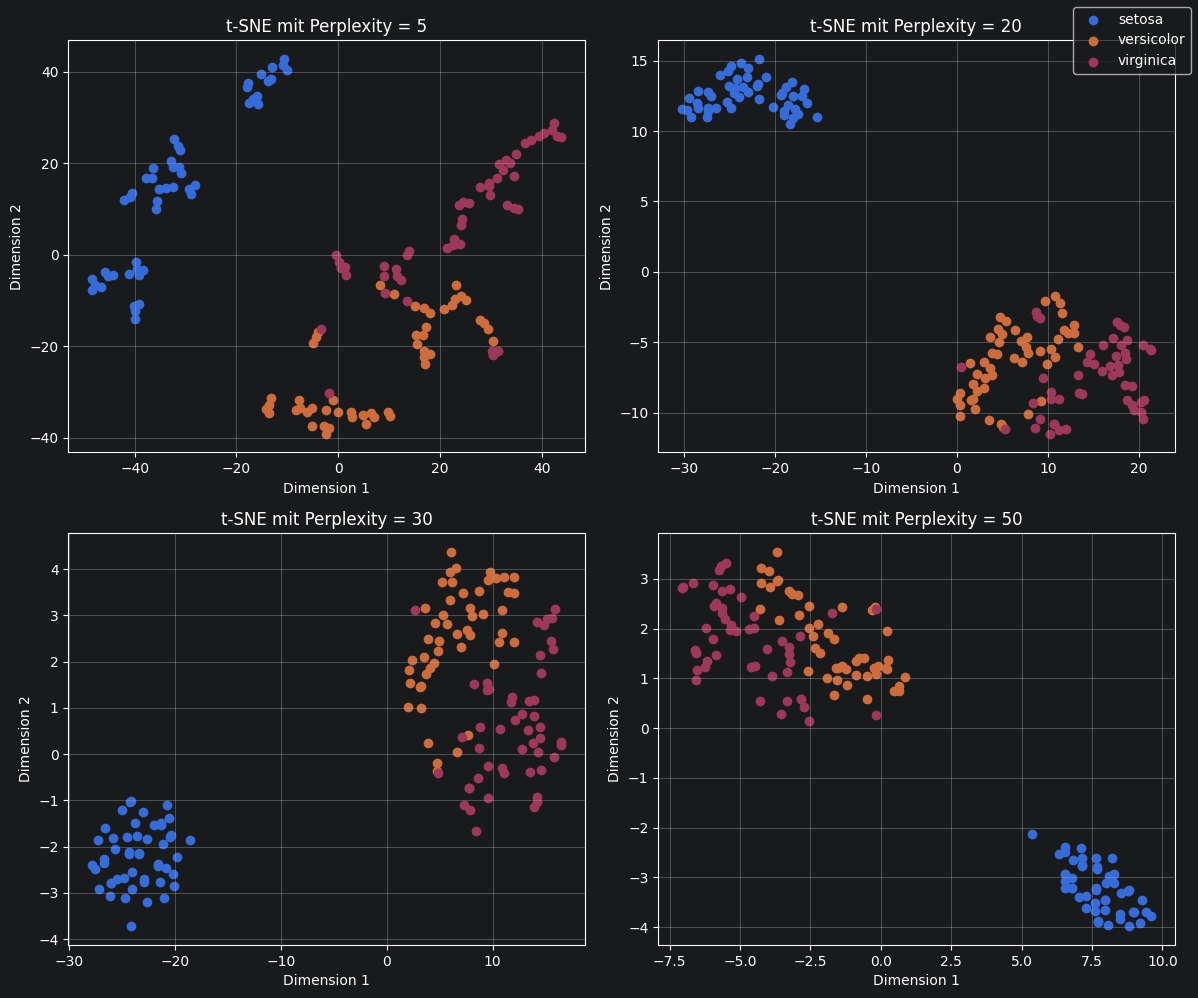

In [14]:
perplexities = [5, 20, 30, 50]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, perplexity in zip(axes.ravel(), perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42
    )
    
    X_tsne_test = tsne.fit_transform(X_scaled)
    
    for class_id, class_name in enumerate(target_names):
        ax.scatter(
            X_tsne_test[y == class_id, 0],
            X_tsne_test[y == class_id, 1],
            label=class_name
        )
    
    ax.set_title(f"t-SNE mit Perplexity = {perplexity}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.grid(True)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

**Beobachtung t-SNE-Hyperparameter:**

`perplexity` beeinflusst, wie viele Nachbarn t-SNE ungefähr bei der lokalen Struktur berücksichtigt. Kleine Werte wie 5 betonen sehr lokale Strukturen. Dadurch können kleinere Gruppen stärker getrennt erscheinen. Mittlere Werte wie 20 oder 30 liefern beim Iris-Datensatz meist eine stabile und gut erkennbare Gruppierung. Größere Werte wie 50 glätten die Darstellung stärker und berücksichtigen mehr globale Struktur.

## e) Vor- und Nachteile diskutieren

**Aufgabenstellung:**

Diskutieren Sie die Vor- und Nachteile von Dimensionsreduktionsmethoden in der Mustererkennung. Berücksichtigen Sie Faktoren wie Qualität der Datenabbildung, die Rechenzeit für die Analyse von Daten und die Interpretierbarkeit der Ergebnisse.

**Teillösung:**

Dimensionsreduktionsmethoden sind in der Mustererkennung hilfreich, weil sie hochdimensionale Daten übersichtlicher machen. Dadurch können Daten visualisiert und spätere Analysen oft beschleunigt werden.

Ein Vorteil von PCA ist, dass die Methode schnell und gut interpretierbar ist. Die Hauptkomponenten beschreiben Richtungen, in denen die Daten besonders stark variieren. Außerdem ist PCA deterministisch, also bei gleichen Daten immer gleich.

Ein Nachteil von PCA ist, dass sie nur lineare Zusammenhänge abbildet. Nichtlineare Strukturen können dadurch verloren gehen. Außerdem kann durch die Reduktion auf wenige Dimensionen wichtige Information verschwinden.

t-SNE ist besonders gut für Visualisierungen geeignet, weil es lokale Nachbarschaften oft sehr anschaulich darstellt. Klassen oder Cluster können dadurch im 2D-Raum sichtbar werden.

Ein Nachteil von t-SNE ist die längere Rechenzeit. Außerdem sind die Ergebnisse stärker von Hyperparametern wie der Perplexity abhängig. Die Achsen eines t-SNE-Plots sind nicht direkt interpretierbar. Deshalb eignet sich t-SNE eher zur explorativen Visualisierung als zur direkten Erklärung einzelner Merkmale.

Für den Iris-Datensatz funktionieren beide Methoden gut. PCA ist einfacher zu interpretieren, während t-SNE häufig eine anschaulichere Gruppierung erzeugt.